# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

In [4]:
# Use self trained K-means results, which have a better likelihood
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

# Fit six areas with 14 conditions

## Set up

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [29]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [30]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Decide couping filter hyperparameters

After many tries, the best hyperparameters for coupling filter is 
peaks_max=50, num=6, nonlinear=0.3

In [52]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

probe_list = V1.selected_probes
select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

trial_state = np.zeros_like(V1.speed)
for i in range(trial_state.shape[1]):
    if V1.running_trial_index[i]:
        trial_state[:,i] = 1.0

model.add_effect('varying_linear', trial_state, num=num_varying_linear)
for j, input_probe in enumerate(probe_list):
    model.add_effect('coupling', probe_list[j], peaks_max=50, num=8, nonlinear=0.3)
model.fit('probeC', verbose=True)

Negative log likelihood is: 59147.40
aic/2 is: 59255.40


## Fit

In [98]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
# use_all = [True, True, False, False, False, True]
use_all = [False, False, False, False, False, False]

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], use_all=use_all[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], use_all=use_all[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI[filter_index] = GLM.get_ROI(function1, function2)
    statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI[filter_index] = GLM.get_ROI(function1, function2)
        statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])

## Excursion test

In [12]:
# Non multiprocessing verison of null distribution
n_null = 10

import copy
fake_running_trial_index = copy.deepcopy(V1.running_trial_index)
statistics_null = {}

for i_null in tqdm(range(n_null)):
    np.random.shuffle(fake_running_trial_index)  
    # don't need to assign shuffled list, it's changed automatically. 
    fake_stationary_trial_index = np.logical_not(fake_running_trial_index)
    running_filter_temp = {}
    stationary_filter_temp = {}
    
    for i, target_probe in enumerate(probe_list):
        select_trials = fake_running_trial_index
        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            model.add_effect('coupling', probe_list[j], peaks_max=100, num=5, nonlinear=0.3)
        model.fit(probe_list[i], verbose=False)
        filter_list = model.get_filter(ci=True)
        running_filter_temp[i,-1] = filter_list[0]
        k = 1
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            running_filter_temp[i,j] = filter_list[k]
            k += 1

        select_trials = fake_stationary_trial_index
        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            model.add_effect('coupling', probe_list[j], peaks_max=100, num=5, nonlinear=0.3)
        model.fit(probe_list[i], verbose=False)
        filter_list = model.get_filter(ci=True)
        stationary_filter_temp[i,-1] = filter_list[0]
        k = 1
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            stationary_filter_temp[i,j] = filter_list[k]
            k += 1

        filter_index = i,-1
        function1 = np.exp( running_filter_temp[filter_index][0] )
        function2 = np.exp( stationary_filter_temp[filter_index][0] )
        if filter_index not in statistics_null.keys():
            statistics_null[filter_index] = []
        statistics_null[filter_index].append( get_excursion_test(function1, function2, ROI[filter_index]) )
        
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            filter_index = i,j
            function1 = running_filter_temp[filter_index][0]
            function2 = stationary_filter_temp[filter_index][0]
            if filter_index not in statistics_null.keys():
                statistics_null[filter_index] = []
            statistics_null[filter_index].append( get_excursion_test(function1, function2, ROI[filter_index]) )

100%|███████████████████████████████████████████| 10/10 [02:00<00:00, 12.04s/it]


In [67]:
from GLM import get_statistics_null_mp
statistics_null = get_statistics_null_mp(1000, V1, membership, condition_ids, probe_list, 
                                         num_basis_baseline, coupling_filter_params)

Starting multiprocessing on linux. 
Cores=5. 
Batch size=50


100%|█████████████████████████████████████| 1000/1000 [1:16:53<00:00,  4.61s/it]


## Results with excursion test

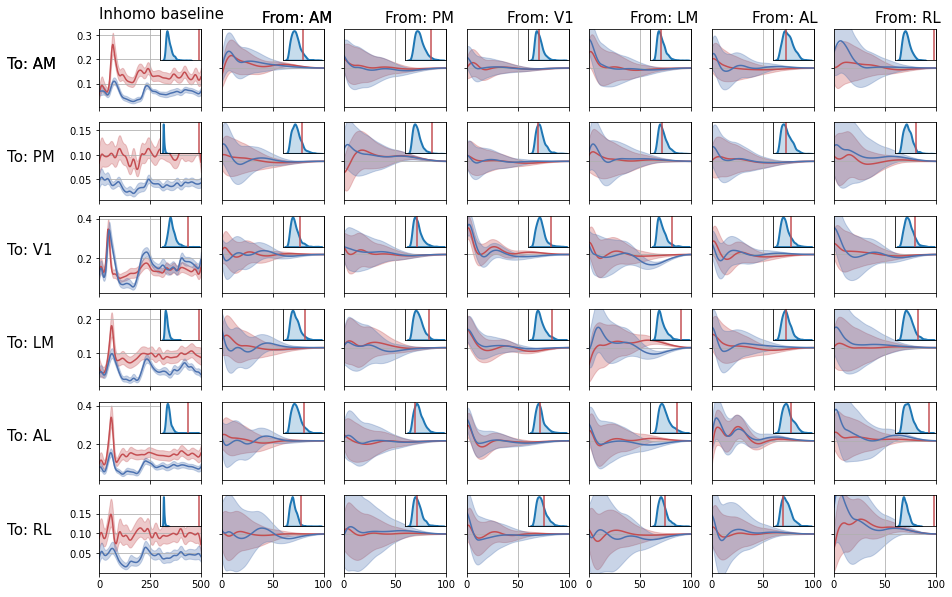

In [99]:
# use_all are all False
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-0.17, 0.17])
            plt.yticks(color='w')
            plt.xticks([0, 50, 100])
            plt.xlim([0, 100])
            if i==0:
                plt.text(40, 0.2, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-210, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        ins = ax.inset_axes([0.6,0.6,0.4,0.4])
        sns.kdeplot(statistics_null[filter_index], linewidth=2, ax=ins, fill=True)
        ins.axvline(statistics[filter_index], linewidth=1.5, color='r')
        ins.set_xticks([])
        ins.set_yticks([])
        ins.set_ylabel('')
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-450, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(40, 0.61, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0, 0.37, f'Inhomo baseline', fontsize=fontsize)



# Mean firing rate

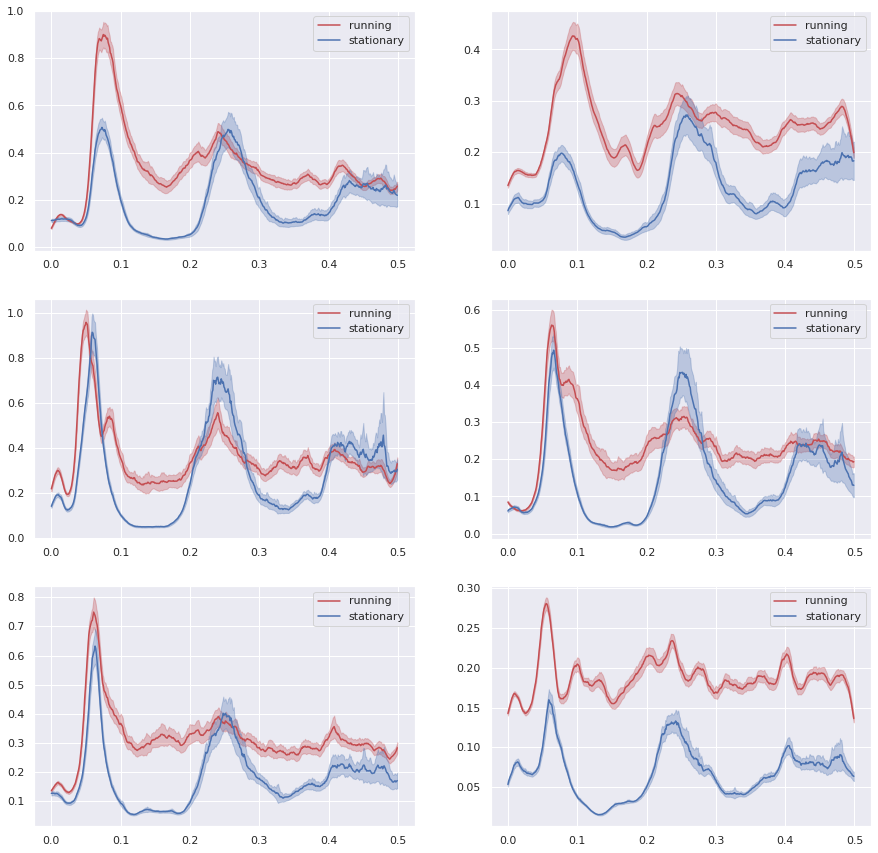

In [72]:
sns.set_theme()
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}
plt.subplots(figsize=(15,15))

for i, target_probe in enumerate(probe_list):
    plt.subplot(3, 2, i+1)
    
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    plot_target = np.exp(model.log_lmbd)
    x = model.dataset.time_line
    y = plot_target.mean(axis=1)
    ci = plot_target.std(axis=1)/np.sqrt(plot_target.shape[1])
    color = 'r'
    label = 'running'
    plt.plot(x, y.squeeze(),label=label, color=color)
    plt.fill_between(x, (y-2*ci), (y+2*ci), color=color, alpha=.3)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    plot_target = np.exp(model.log_lmbd)
    x = model.dataset.time_line
    y = plot_target.mean(axis=1)
    ci = plot_target.std(axis=1)/np.sqrt(plot_target.shape[1])
    color = 'b'
    label = 'stationary'
    plt.plot(x, y.squeeze(),label=label, color=color)
    plt.fill_between(x, (y-2*ci), (y+2*ci), color=color, alpha=.3)
    plt.legend()

# Contributions of each effect

In [367]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_output(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_output(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI[filter_index] = GLM.get_ROI(function1, function2)
    statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI[filter_index] = GLM.get_ROI(function1, function2)
        statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])

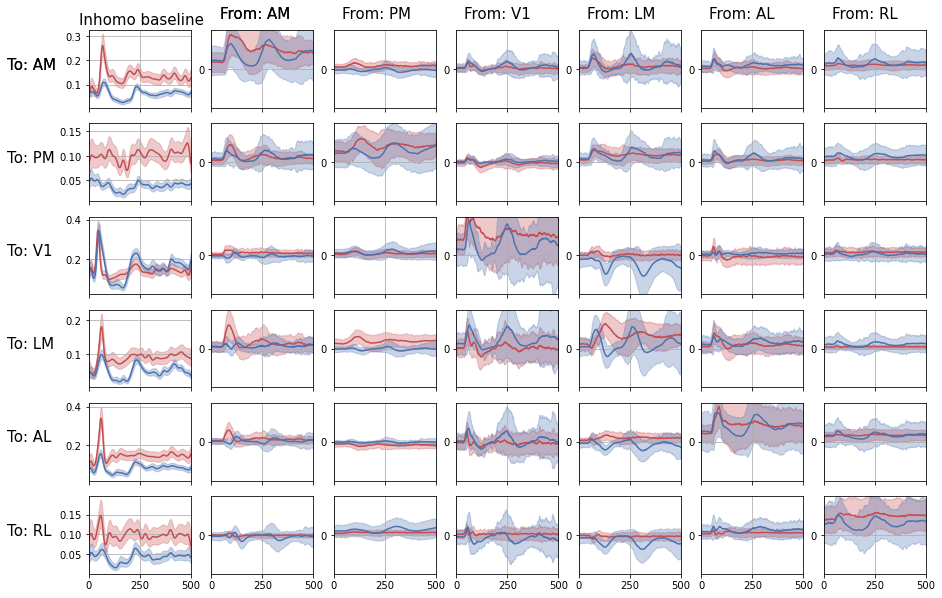

In [368]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize=15

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-1, 1])
#             plt.yticks(color='w')
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            if i==0:
                plt.text(40, 1.3, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-1000, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-2200, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(40, 3.7, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-50, 0.35, f'Inhomo baseline', fontsize=fontsize)
